# Семинар 2. EM-алгоритм, kallisto

## EM-алгоритм

Загрузка датасета, с которым будем работать

In [ ]:
!gdown --id 17mf6RUEFOJ19t2zNuFlswSUs7MODwLlk

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17mf6RUEFOJ19t2zNuFlswSUs7MODwLlk
To: /content/EM_dataset.csv
100% 12.6k/12.6k [00:00<00:00, 46.0MB/s]


Поъстроим `Диаграмму рассеяния` (scatterplot)

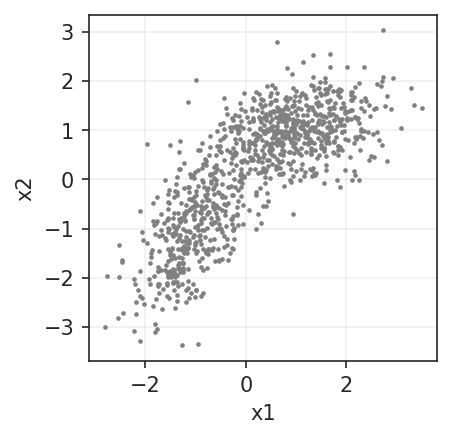

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("ticks")
df = pd.read_csv("EM_dataset.csv")
fig, ax = plt.subplots(figsize=(3,3), dpi=150)
sns.scatterplot(x='x1', y='x2', data=df, s=5, color='grey', linewidth=0, ax=ax)
ax.grid(alpha=0.3)

**Априорная вероятность**, что точка принадлежит кластеру (1) – $P(B_1)$ далее обозначается $ϕ$ (тогда ко второму – $1-\phi$)

In [ ]:
import numpy as np

def get_random_psd(n=2):
    """
    Задает Дисперсию многомерной гауссианы
    (матрицу ковариаций)
    """
    x = np.random.normal(0, 1, size=(n,n))
    return np.dot(x, x.transpose())

params = {
    "phi" : np.random.uniform(0, 1), # Априорная вероятность B1, доля точек в (1)

    "mu1" : np.random.normal(0, 1, size=2), # Начальное мат ожидание (1)
    "mu2" : np.random.normal(0, 1, size=2), # Начальное мат ожидание (2)

    "sigma1" : get_random_psd(),
    "sigma2" : get_random_psd(),
}

for param in params:
    print(f"{param}:")
    print(params[param], "\n")

phi:
0.95179521734672 

mu1:
[ 0.40389348 -0.56699319] 

mu2:
[-0.17715708  0.54382841] 

sigma1:
[[0.32936002 0.12696567]
 [0.12696567 2.35338891]] 

sigma2:
[[ 7.4640438  -0.66200417]
 [-0.66200417  0.0599752 ]] 



Визуализация инициализированных распределений (вместе с точками сета)

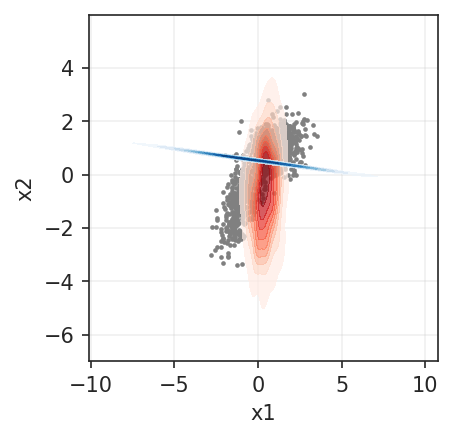

In [ ]:
import scipy.stats as stats

hist1 = stats.multivariate_normal(params["mu1"], params["sigma1"]).rvs(size=1000)
hist2 = stats.multivariate_normal(params["mu2"], params["sigma2"]).rvs(size=1000)

fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
sns.scatterplot(x="x1", y="x2", data=df, s=5, linewidth=0, ax=ax, color="grey")
sns.kdeplot(x=hist1[:, 0], y=hist1[:, 1], ax=ax, cmap="Reds", fill=True, alpha=0.7)
sns.kdeplot(x=hist2[:, 0], y=hist2[:, 1], ax=ax, cmap="Blues", fill=True, alpha=0.7)
ax.grid(alpha=0.3)

### E-шаг

Для определения вероятности принадлежности точки к кадому из кластеров воспользуемся логарифмической формой теоремы Байеса:
$$b_i = \log P(B_j|x_i) = \log P(B_j) + \log P(x_i|B_j) - \log P(x_i)$$

In [ ]:
# Объяснение из след. ячейки

x = df.values # Массив значений
gaussian_2d = stats.multivariate_normal(params['mu1'], params['sigma1']) # Двумерная гауссиана со средним mu1 и дисперсией sigma1
gaussian_2d.pdf(x) # Вернет правдоподобие (likelihood) того что точки из массива х порождены это гаусианной


array([6.41965709e-02, 2.51317283e-05, 1.14780937e-01, 8.09818651e-03,
       3.07947926e-05, 1.37304674e-01, 1.09646382e-01, 3.56855301e-03,
       8.21699338e-02, 1.15031756e-02, 6.57260407e-02, 1.01061024e-01,
       3.02785729e-02, 4.60006922e-02, 4.32249794e-05, 4.83035334e-02,
       5.40885043e-02, 2.98390574e-02, 9.21814743e-02, 1.20023262e-03,
       1.26301339e-01, 1.04778413e-01, 2.15852910e-02, 4.95548908e-02,
       4.83536632e-02, 2.76127688e-02, 1.52004979e-03, 4.79296626e-04,
       7.04859884e-04, 4.95383315e-02, 8.00233269e-02, 6.74212550e-02,
       5.09846908e-02, 7.62907688e-02, 3.03064353e-03, 1.47498302e-01,
       1.30704556e-01, 1.04221560e-01, 1.13834212e-01, 9.38240767e-03,
       1.07752006e-01, 1.93164833e-03, 4.50200642e-03, 1.40146160e-01,
       3.19018470e-03, 1.56089079e-04, 2.09388200e-02, 6.12638479e-03,
       9.81126934e-04, 6.17559961e-02, 7.08004906e-03, 4.92894941e-02,
       8.77164505e-02, 1.95218456e-05, 4.38776066e-02, 1.12052567e-01,
      

In [ ]:
from scipy.special import logsumexp

x = df.values

def E_step(x, params, draw=False):
    log_P_x_B = logLikelihood = A = np.log([
        stats.multivariate_normal(params['mu1'], params['sigma1']).pdf(x),
        stats.multivariate_normal(params['mu2'], params['sigma2']).pdf(x),
    ])
    log_P_B = logPrior = B = np.log([1 - params['phi'], params['phi']])
    log_P_B__P_x_B = logPosterior = logLikelihood.T + logPrior # Значение числителя в т.Байеса
    RealSoftMax = C = logsumexp(logPosterior, axis=1) # Логарифм суммы экспонент членов массива по осям. Т.е. быстрый расчет общей веростности
    probabilities = np.exp(logPosterior - np.array([RealSoftMax]).T) # Вероятность принадлежности точки к (1) и к (2), сум=1

    if draw:
        hist1 = stats.multivariate_normal(params["mu1"], params["sigma1"]).rvs(size=1000)
        hist2 = stats.multivariate_normal(params["mu2"], params["sigma2"]).rvs(size=1000)

        fig, axes = plt.subplots(figsize=(6, 3), dpi=150, ncols=2)
        sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=probabilities[:, 0], linewidth=0,
                        palette="coolwarm", ax=axes[1], s=3, alpha=1) # Отрисовывает вероятность принадлежности только к (1)
        sns.scatterplot(x=x[:, 0], y=x[:, 1], linewidth=0, ax=axes[0], s=3, alpha=1, color="grey")
        sns.kdeplot(x=hist1[:, 0], y=hist1[:, 1], ax=axes[0], cmap="Reds", fill=True, alpha=0.5)
        sns.kdeplot(x=hist2[:, 0], y=hist2[:, 1], ax=axes[0], cmap="Blues", fill=True, alpha=0.5)
        axes[0].grid(alpha=0.3)
        axes[1].grid(alpha=0.3)
        axes[1].legend().remove()
        axes[0].set_xlim(-4, 4)
        axes[1].set_xlim(-4, 4)
        axes[0].set_ylim(-4, 4)
        axes[1].set_ylim(-4, 4)
        plt.show()

    return RealSoftMax, probabilities


<ipython-input-44-0874049d0a0e>:6: RuntimeWarning: divide by zero encountered in log
  log_P_x_B = logLikelihood = A = np.log([


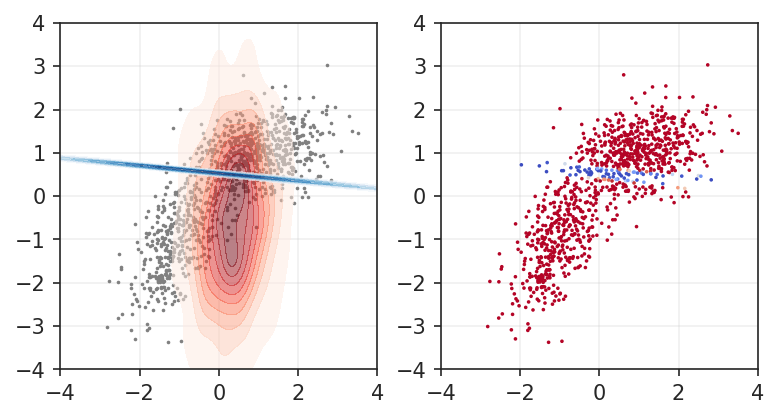

In [ ]:
total_prob, probabilities = E_step(x, params, draw=True)

In [ ]:
def M_step(x, params, probabilities):
    prob_1 = probabilities[:, 0]
    prob_2 = probabilities[:, 1]

    # Вычисление новых значений

    # Phi - P(B_j) - Prior
    phi = prob_1.sum() / len(x)

    # Средние / мат. ожидание
    mu1 = prob_1.dot(x) / np.sum(prob_1)
    mu2 = prob_2.dot(x) / np.sum(prob_2)

    # Дисперсии
    sigma1 = (x - mu1).T.dot((x - mu1) * np.array([prob_1]).T) / np.sum(prob_1)
    sigma2 = (x - mu2).T.dot((x - mu2) * np.array([prob_2]).T) / np.sum(prob_2)

    return {
        "phi" : phi,
        "mu1" : mu1,
        "mu2" : mu2,
        "sigma1" : sigma1,
        "sigma2" : sigma2
    }

Сделаем так, чтобы это выполнялось до тех пор, пока общая вероятность не перестанет уменьшаться меньше, чем на 0.0001.

In [ ]:
def run_EM(X, params, draw=False):
    import imageio
    avg_total_prob = []

    while True:
        total_prob, probabilities = E_step(X, params, draw=draw)
        avg_total_prob.append(np.mean(total_prob))
        if len(avg_total_prob) > 2 and abs(avg_total_prob[-1] - avg_total_prob[-2]) < 0.00001:
            break
        params = M_step(X, params, probabilities)

    loglikelihood, probabilities = E_step(X, params)
    forecasts = np.argmax(probabilities, axis=1)
    return forecasts, probabilities, avg_total_prob

<ipython-input-44-0874049d0a0e>:6: RuntimeWarning: divide by zero encountered in log
  log_P_x_B = logLikelihood = A = np.log([


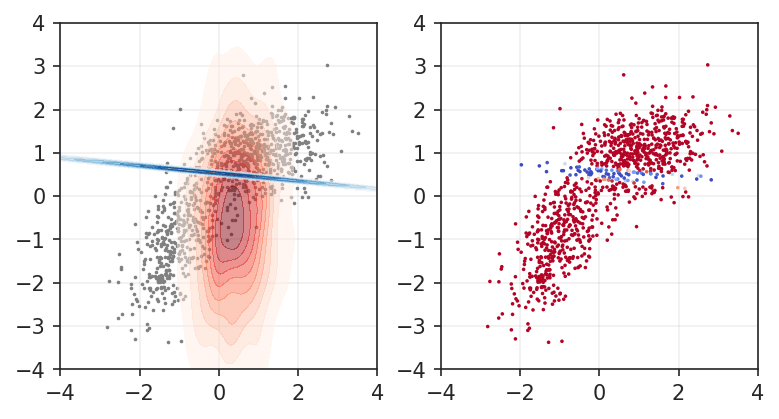

<ipython-input-44-0874049d0a0e>:6: RuntimeWarning: divide by zero encountered in log
  log_P_x_B = logLikelihood = A = np.log([


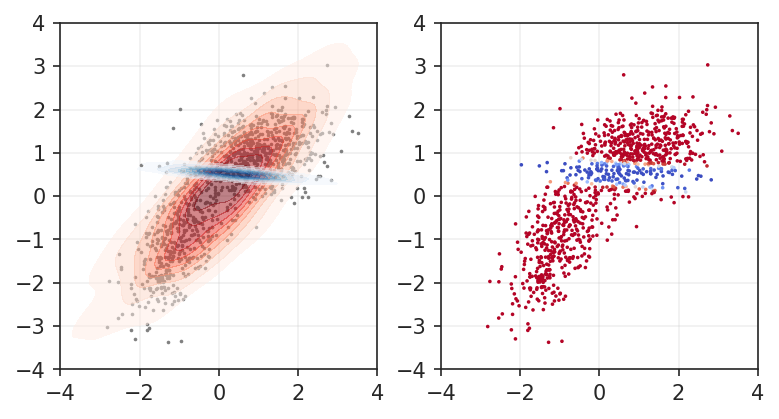

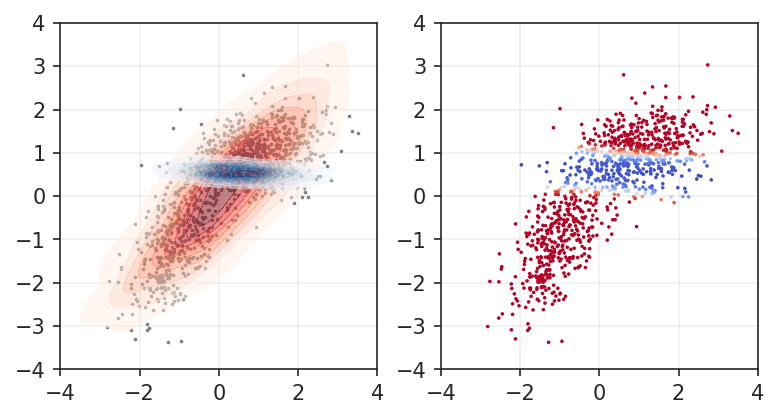

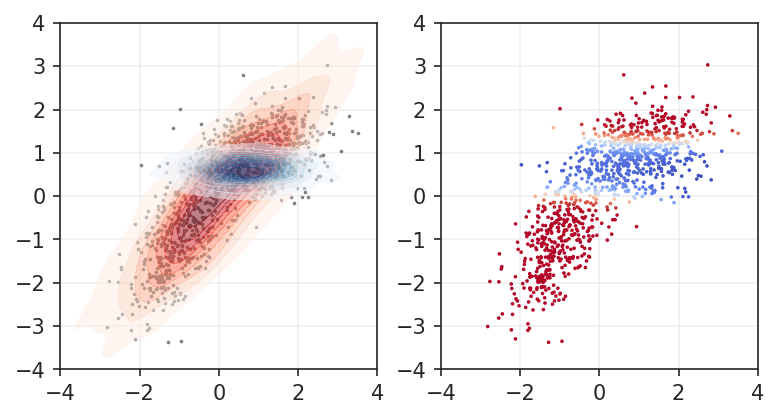

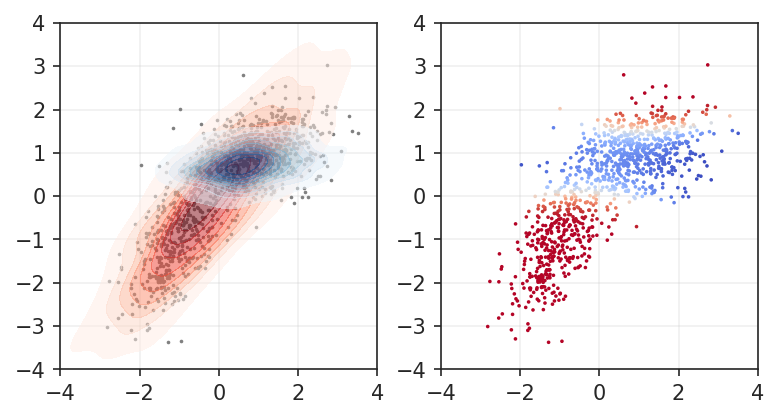

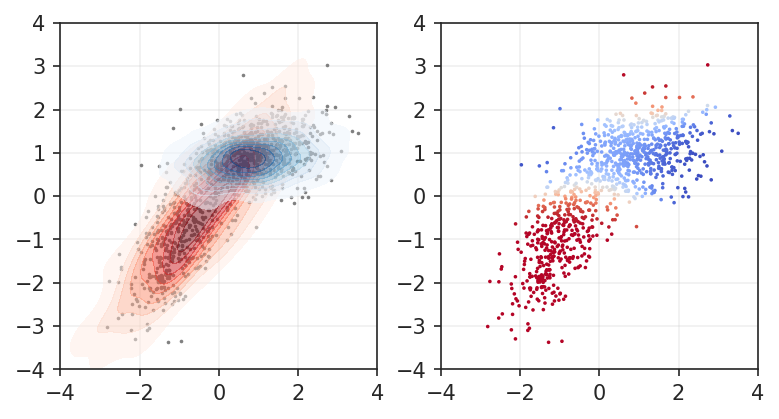

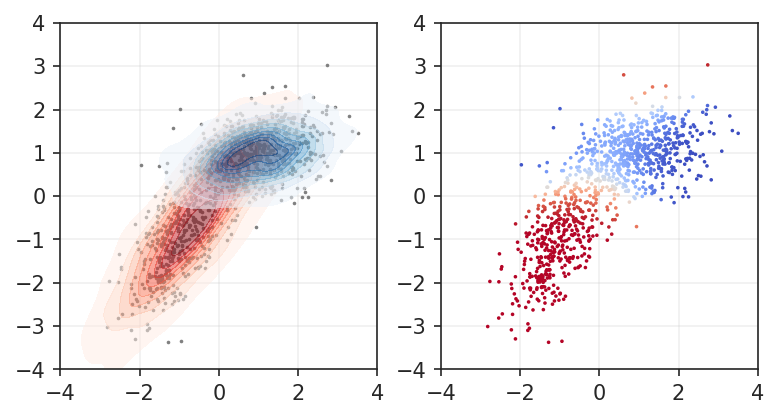

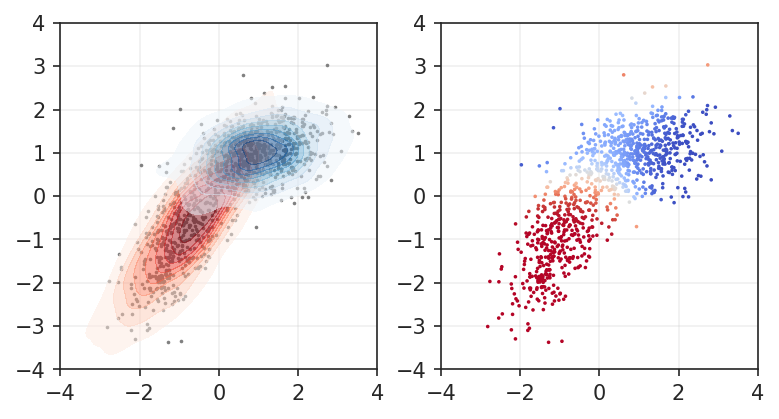

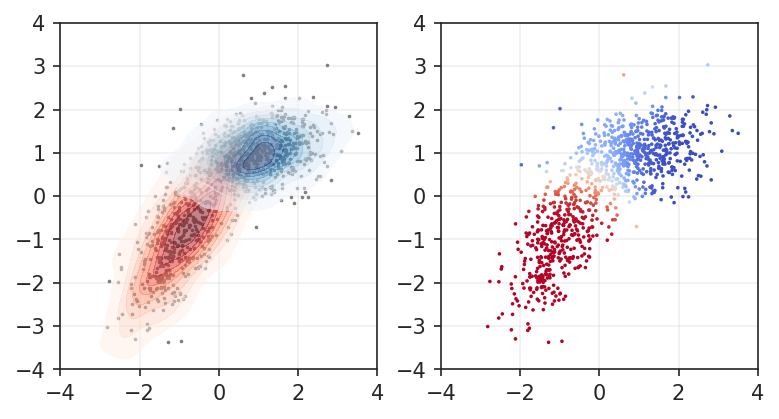

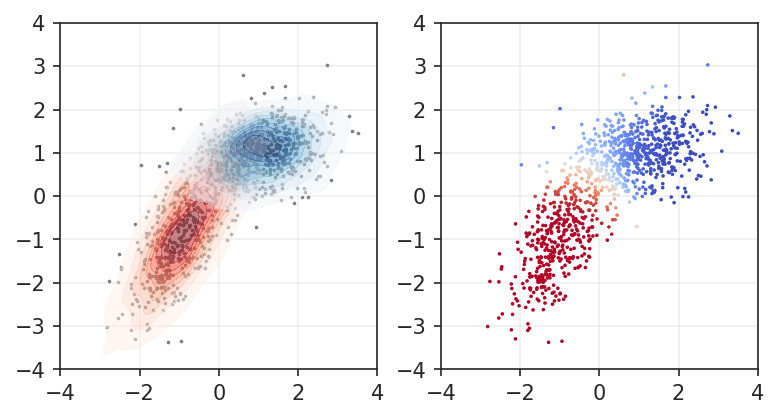

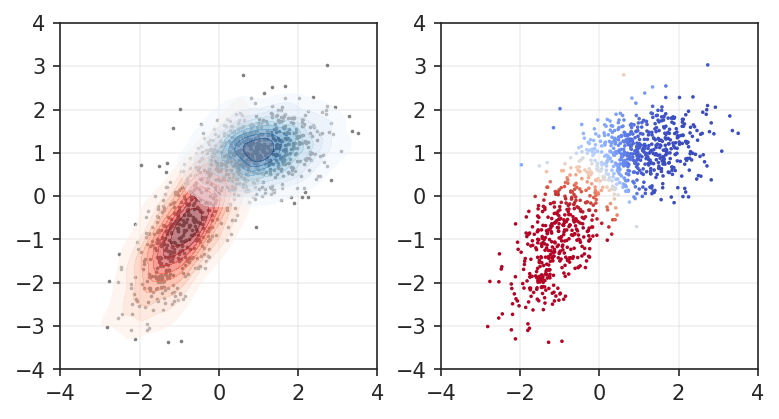

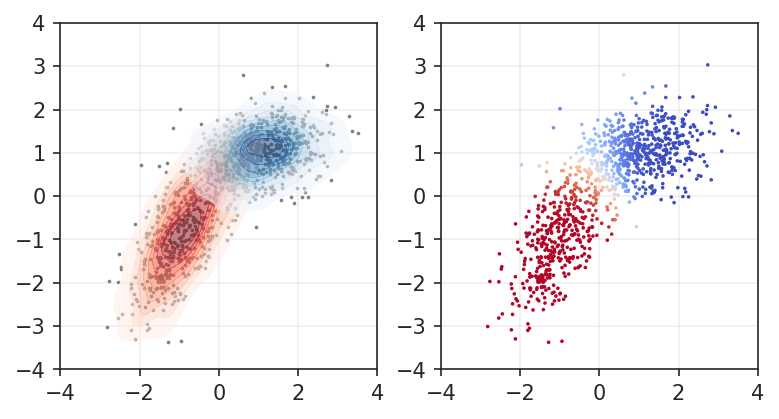

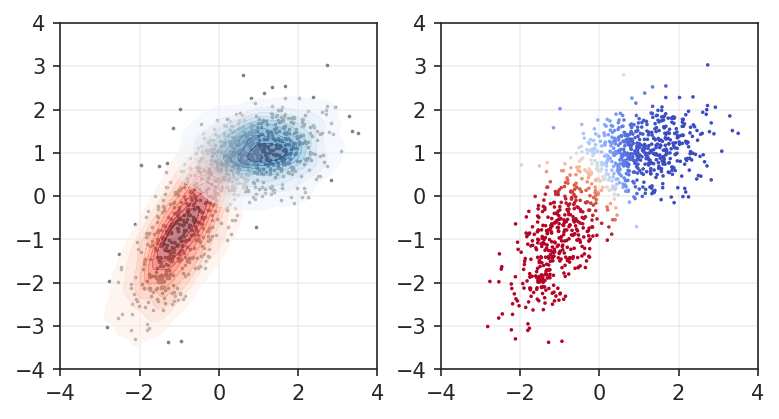

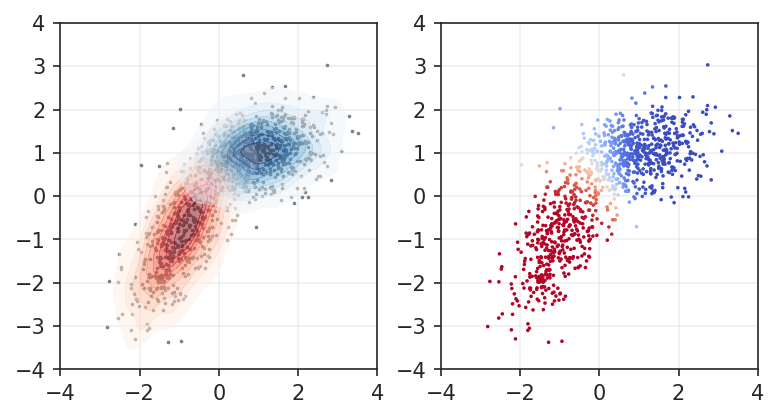

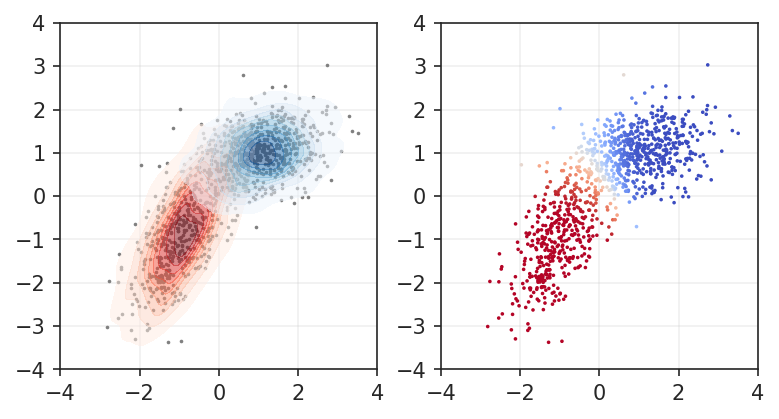

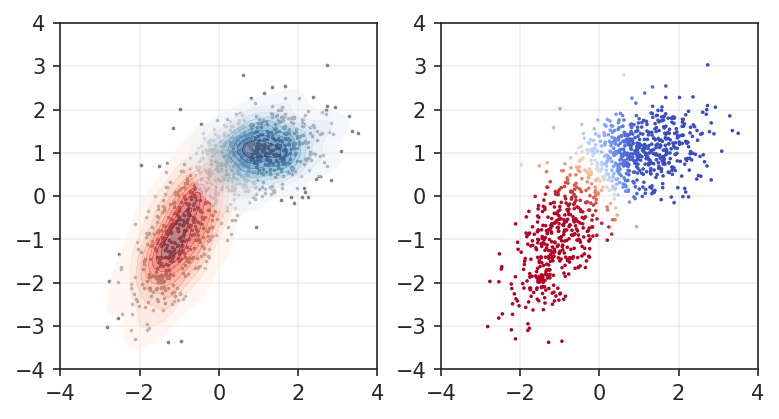

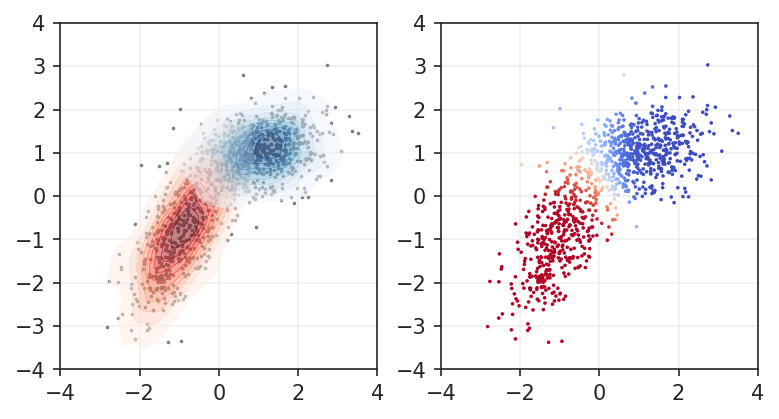

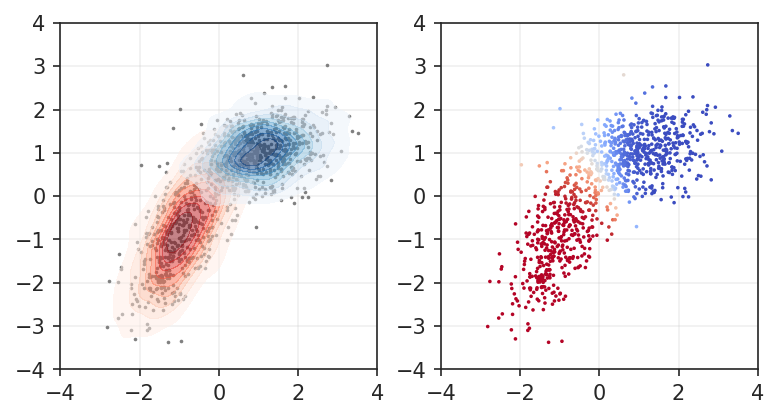

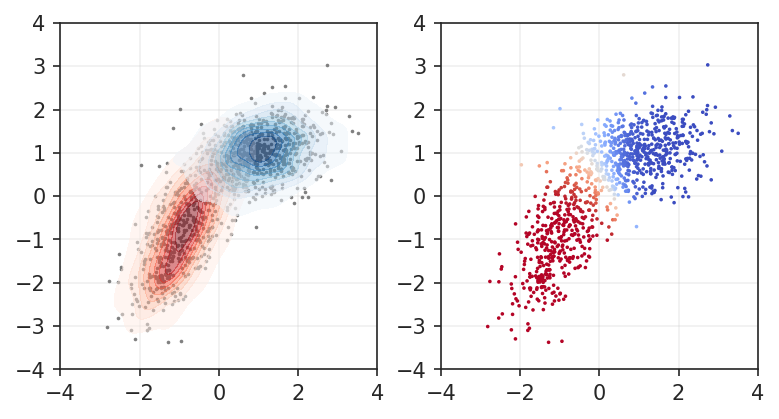

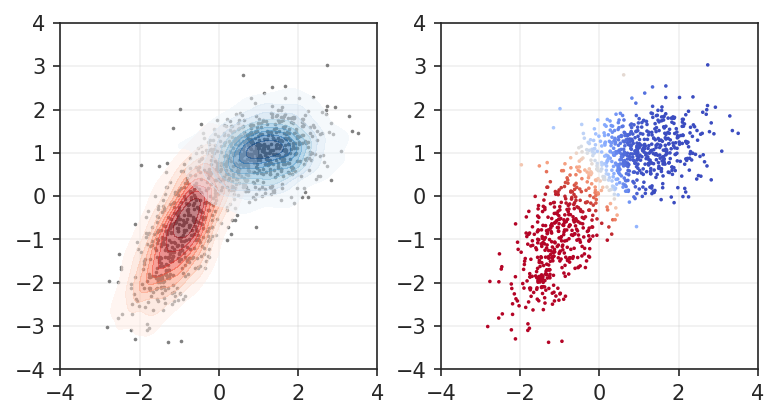

In [ ]:
pred, prob, allprob = run_EM(x, params, draw=True)

# Kallisto

In [ ]:
!git clone https://github.com/pachterlab/kallisto.git
!apt-get install autoconf
!cd kallisto && mkdir build && cd build && cmake .. && make

Теперь смоделируем следующую ситуацию:

1. У нас есть линейный геном, который состоит из $N_{blocks}$ блоков длиной $l_{block}$,
2. У нас есть $M$ транскриптов, каждый из которых включает несколько из геномных блоков,
3. Для каждого из транскриптов известен его уровень экспрессии $E_i$ в количестве молекул РНК. Каждая молекула РНК генерирует $l_{t} / 1000$ прочтений.

Давайте сгенерируем такой референсный транскриптом, а также прочтения, которые будут генерироваться при таком *in silico* RNA-Seq-эксперименте. Будем считать, что все прочтения были идеальными, качество у них `I`.

In [ ]:
# Generation of sequence
N_blocks = 10 # Геном состоит из 10 блоков
l_block = 5000 # Кажддый по 5kb
transcripts = { # Каждый транскрипт включает случайный блоки генома
    "A" : [0, 1, 2],
    "B" : [1, 3],
    "C" : [1, 4, 9],  # Некоторые транскрипты пересекаются
    "D" : [9],
    "E" : [5, 6],
    "F" : [8, 9]
}

def generate_random_sequence(l):
  from random import choice
  return "".join([choice(["A", "T", "G", "C"]) for i in range(l)])

genome_blocks = dict(zip(range(10), [generate_random_sequence(l_block) for i in range(10)]))

# Generation of reference transcriptome
transcript_sequences = {}
with open("transcriptome.fasta", "w") as f:
  for transcript in transcripts:
    transcript_sequences[transcript] = "".join([genome_blocks[i] for i in transcripts[transcript]])
    f.write(f">{transcript}\n{transcript_sequences[transcript]}\n")

In [ ]:
# Generation of reads
from tqdm.notebook import tqdm

l_read = 100
E = {
    "A" : 100, # ПсевдоУровень Псевдоэкспресси транскриптов
    "B" : 100,
    "C" : 100,
    "D" : 50,
    "E" : 20,
    "F" : 10
}

from random import randint
with open("reads.fastq", "w") as f:
  counter = 0
  for transcript in E:
    for i in tqdm(range(E[transcript])):
      for j in range(len(transcript_sequences[transcript]) // 100):
        read_start = randint(0, len(transcript_sequences[transcript]) - (l_read + 1))
        quality = "I" * (l_read + 40)
        f.write(f"@read_{counter}\n{generate_random_sequence(20)}{transcript_sequences[transcript][read_start:(read_start + l_read)]}{generate_random_sequence(20)}\n+\n{quality}\n")
        counter += 1

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Теперь создадим индекс с нашим референсом при помощи `kallisto index`:

In [ ]:
!./kallisto/build/src/kallisto index -i transcriptome.idx transcriptome.fasta


[build] loading fasta file transcriptome.fasta
[build] k-mer length: 31
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Finished
CompactedDBG::build(): Estimated number of k-mers occurring at least once: 45200
CompactedDBG::build(): Estimated number of minimizer occurring at least once: 11213
CompactedDBG::filter(): Processed 64820 k-mers in 6 reads
CompactedDBG::filter(): Found 44893 unique k-mers
CompactedDBG::filter(): Number of blocks in Bloom filter is 310
CompactedDBG::construct(): Extract approximate unitigs (1/2)
CompactedDBG::construct(): Extract approximate unitigs (2/2)
CompactedDBG::construct(): Closed all input files

CompactedDBG::construct(): Splitting unitigs (1/2)

CompactedDBG::construct(): Splitting unitigs (2/2)
CompactedDBG::construct(): Before split: 23 unitigs
CompactedDBG::construct(): After split (1/1): 23 unitigs
CompactedDBG::

А теперь подсчитаем наши экспрессии при помощи `kallisto quant`:

In [ ]:
l = l_read                                                       #    / отсюда только для односторонных прочтений
!./kallisto/build/src/kallisto quant -i transcriptome.idx -o results --single -l $l -s 1 reads.fastq


[quant] fragment length distribution is truncated gaussian with mean = 100, sd = 1
[index] k-mer length: 31
[index] number of targets: 6
[index] number of k-mers: 44,939
[quant] running in single-end mode
[quant] will process file 1: reads.fastq
[quant] finding pseudoalignments for the reads ... done
[quant] processed 45,500 reads, 45,500 reads pseudoaligned
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 52 rounds



Теперь сравним, какое распределение экспрессий мы подали в самом начале, и что мы получили на выходе из kallisto. Нам нужен будет файл `abundance.tsv`, а конкретно столбец `TPM` (что это такое мы разберём на следующей лекции):

In [ ]:
results = pd.read_csv("results/abundance.tsv", sep="\t", index_col=0)
E_truth = dict(zip(E.keys(), [[i] for i in E.values()]))
df = pd.DataFrame(E_truth, index=["expression_truth"]).T
df["expression_pred"] = results["tpm"]
df.expression_truth = df.expression_truth / df.expression_truth.sum()
df.expression_pred = df.expression_pred / df.expression_pred.sum()
df['Δ*10 000'] = np.abs(df['expression_truth'] - df['expression_pred'])*10000
df

,expression_truth,expression_pred,Δ*10 000
A,0.263158,0.262856,3.019473
B,0.263158,0.264040,8.820525
C,0.263158,0.260641,25.169469
D,0.131579,0.134784,32.050257
E,0.052632,0.052585,0.469895
F,0.026316,0.025095,12.211945
